In [ ]:
import os

# Define project root name
project_root = "project-root"

# List of subdirectories
folders = [
    "calibration",
    "dataset",
    "models",
    "inference",
    "measurement",
    "docs"
]

# Create project root
os.makedirs(project_root, exist_ok=True)

# Create subdirectories
for folder in folders:
    os.makedirs(os.path.join(project_root, folder), exist_ok=True)

# Create empty files
open(os.path.join(project_root, "requirements.txt"), "w").close()
open(os.path.join(project_root, "README.md"), "w").close()

print("✅ Project structure created!")

✅ Project structure created!


In [ ]:
!pip install opencv-python

In [ ]:
import shutil
import os

REPO = "/content/computer-vision-internship-assessment"

# Copy notebook
shutil.copy(
    "/content/drive/MyDrive/Internship_task.ipynb",
    REPO
)

# Copy project-root
shutil.copytree(
    "/content/drive/MyDrive/project-root",
    os.path.join(REPO, "project-root"),
    dirs_exist_ok=True
)

print("Files copied successfully.")

Files copied successfully.


In [ ]:
%run "/content/drive/MyDrive/project-root/calibration/calibration.py"

hello3
Images found: 20
[OK] image_12.jpeg
[OK] image_01.jpeg
[OK] image_16.jpeg
[OK] image_02.jpeg
[OK] image_07.jpeg
[OK] image_08.jpeg
[OK] image_15.jpeg
[OK] image_17.jpeg
[OK] image_18.jpeg
[OK] image_14.jpeg
[OK] image_06.jpeg
[OK] image_19.jpeg
[OK] image_13.jpeg
[OK] image_05.jpeg
[OK] image_04.jpeg
[OK] image_10.jpeg
[OK] image_11.jpeg
[OK] image_03.jpeg
[OK] image_20.jpeg
[OK] image_09.jpeg

Successful detections: 20

CAMERA CALIBRATION RESULTS

Camera Matrix:
[[1.38415842e+03 0.00000000e+00 6.16843935e+02]
 [0.00000000e+00 1.37951259e+03 6.04613397e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
[[-2.50310364e-01  9.95439938e-01 -2.16423170e-03 -4.79003971e-04
  -1.48795151e+00]]

Reprojection Error:
0.23616686

Camera parameters saved to:
camera_params.npz


STEP2: setting Dataset images for the project


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/project-root"

RAW_DIR = os.path.join(PROJECT_ROOT, "dataset", "raw")
UNDISTORTED_DIR = os.path.join(PROJECT_ROOT, "dataset", "undistorted")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(UNDISTORTED_DIR, exist_ok=True)

print("Raw:", RAW_DIR)
print("Undistorted:", UNDISTORTED_DIR)

Raw: /content/drive/MyDrive/project-root/dataset/raw
Undistorted: /content/drive/MyDrive/project-root/dataset/undistorted


In [ ]:
import glob
import os

images = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    images.extend(glob.glob(os.path.join(RAW_DIR, ext)))

print("Images found:", len(images))

Images found: 100


In [ ]:
%%writefile /content/drive/MyDrive/project-root/calibration/undistort.py

import cv2
import numpy as np
import glob
import os

# ==============================
# PATHS
# ==============================

PROJECT_ROOT = "/content/drive/MyDrive/project-root"

PARAMS_PATH = os.path.join(
    PROJECT_ROOT,
    "calibration",
    "camera_params.npz"
)

INPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "raw"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "undistorted"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==============================
# LOAD CAMERA PARAMETERS
# ==============================

data = np.load(PARAMS_PATH)

camera_matrix = data["camera_matrix"]
distortion_coefficients = data["distortion_coefficients"]

print("Camera parameters loaded.")
print("Camera matrix:")
print(camera_matrix)

print("\nDistortion coefficients:")
print(distortion_coefficients)


# ==============================
# FIND IMAGES
# ==============================

image_paths = []

for extension in [
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.JPG",
    "*.JPEG",
    "*.PNG"
]:
    image_paths.extend(
        glob.glob(
            os.path.join(INPUT_DIR, extension)
        )
    )

print("\nImages found:", len(image_paths))


# ==============================
# UNDISTORT IMAGES
# ==============================

successful = 0

for image_path in image_paths:

    image = cv2.imread(image_path)

    if image is None:
        print("[FAILED TO READ]", image_path)
        continue

    undistorted = cv2.undistort(
        image,
        camera_matrix,
        distortion_coefficients
    )

    filename = os.path.basename(image_path)

    output_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    cv2.imwrite(
        output_path,
        undistorted
    )

    successful += 1

    print("[OK]", filename)


# ==============================
# SUMMARY
# ==============================

print("\n==============================")
print("UNDISTORTION COMPLETE")
print("==============================")

print("Input images:", len(image_paths))
print("Successful:", successful)
print("Output directory:")
print(OUTPUT_DIR)

Overwriting /content/drive/MyDrive/project-root/calibration/undistort.py


In [ ]:
%run "/content/drive/MyDrive/project-root/calibration/undistort.py"

Camera parameters loaded.
Camera matrix:
[[1.38415842e+03 0.00000000e+00 6.16843935e+02]
 [0.00000000e+00 1.37951259e+03 6.04613397e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[[-2.50310364e-01  9.95439938e-01 -2.16423170e-03 -4.79003971e-04
  -1.48795151e+00]]

Images found: 100
[OK] image2.jpeg
[OK] image3.jpeg
[OK] image5.jpeg
[OK] image4.jpeg
[OK] image1.jpeg
[OK] image6.jpeg
[OK] image9.jpeg
[OK] image7.jpeg
[OK] image10.jpeg
[OK] image12.jpeg
[OK] image11.jpeg
[OK] image8.jpeg
[OK] image13.jpeg
[OK] image15.jpeg
[OK] image17.jpeg
[OK] image16.jpeg
[OK] image14.jpeg
[OK] image18.jpeg
[OK] image20.jpeg
[OK] image19.jpeg
[OK] image21.jpeg
[OK] image23.jpeg
[OK] image22.jpeg
[OK] image24.jpeg
[OK] image27.jpeg
[OK] image26.jpeg
[OK] image25.jpeg
[OK] image29.jpeg
[OK] image28.jpeg
[OK] image32.jpeg
[OK] image30.jpeg
[OK] image31.jpeg
[OK] image35.jpeg
[OK] image36.jpeg
[OK] image33.jpeg
[OK] image37.jpeg
[OK] image34.jpeg
[OK] image38.jpeg
[OK] ima

Comparing real image and undistored images


Images found: 100
Original: image2.jpeg
Undistorted: image2.jpeg
Original loaded: True
Undistorted loaded: True


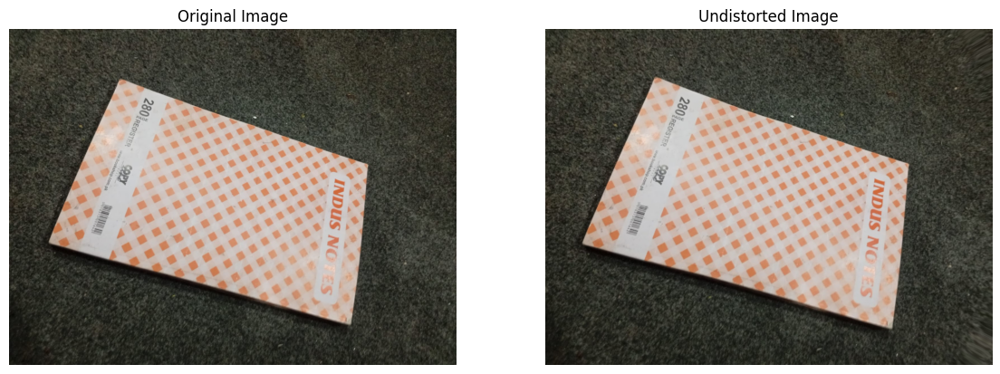

In [ ]:
import cv2
import matplotlib.pyplot as plt
import glob
import os

PROJECT_ROOT = "/content/drive/MyDrive/project-root"

RAW_DIR = os.path.join(PROJECT_ROOT, "dataset", "raw")
UNDISTORTED_DIR = os.path.join(PROJECT_ROOT, "dataset", "undistorted")

# Find images
image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_files.extend(glob.glob(os.path.join(RAW_DIR, ext)))

print("Images found:", len(image_files))

# Select first image
original_path = image_files[0]
filename = os.path.basename(original_path)
undistorted_path = os.path.join(UNDISTORTED_DIR, filename)

print("Original:", filename)
print("Undistorted:", filename)

# Load images
original = cv2.imread(original_path)
undistorted = cv2.imread(undistorted_path)

print("Original loaded:", original is not None)
print("Undistorted loaded:", undistorted is not None)

# Convert BGR → RGB
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_rgb)
plt.title("Undistorted Image")
plt.axis("off")

plt.show()

Showing annotations images


In [ ]:
import json
import cv2
import matplotlib.pyplot as plt
import os

# Paths
IMAGE_DIR = "/content/drive/MyDrive/project-root/dataset/undistorted"
COCO_JSON = "/content/drive/MyDrive/project-root/dataset/annotations/annotations.json"

# Load COCO annotations
with open(COCO_JSON, "r") as f:
    coco = json.load(f)

# Create image_id -> image information
image_info = {img["id"]: img for img in coco["images"]}

# Create image_id -> annotation
annotations = {}
for ann in coco["annotations"]:
    annotations[ann["image_id"]] = ann

print("Images:", len(coco["images"]))
print("Annotations:", len(coco["annotations"]))

Images: 100
Annotations: 100


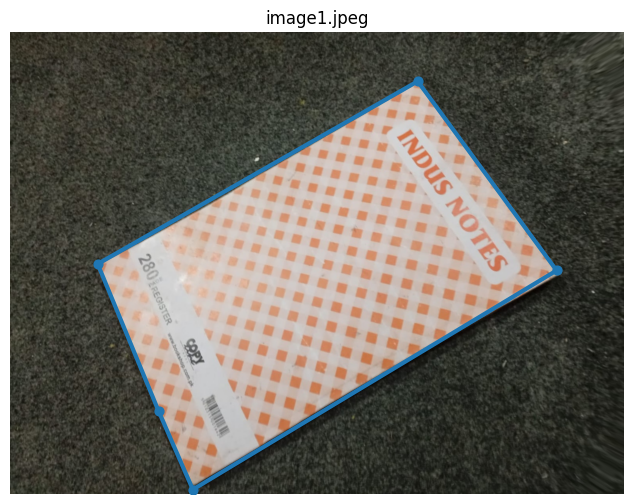

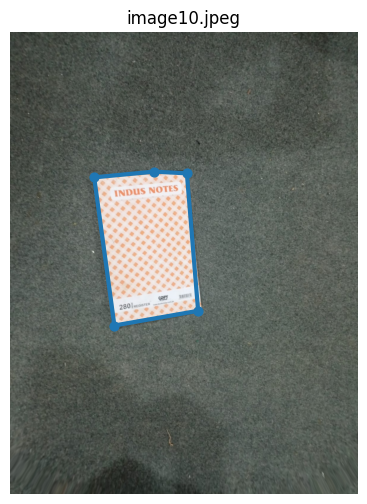

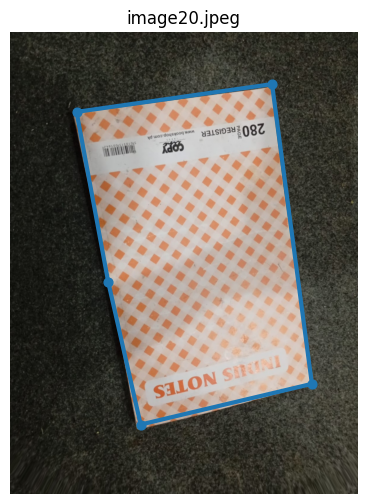

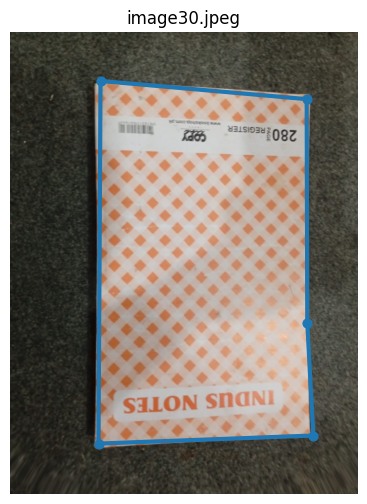

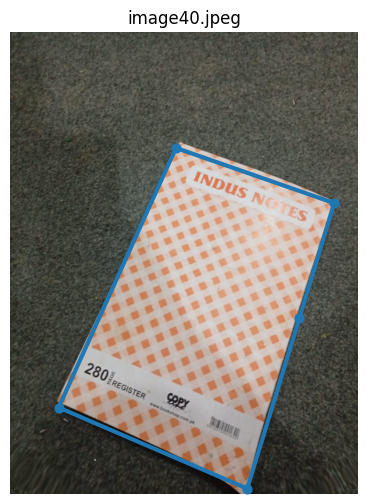

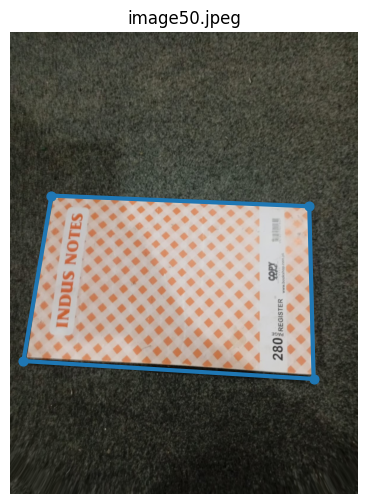

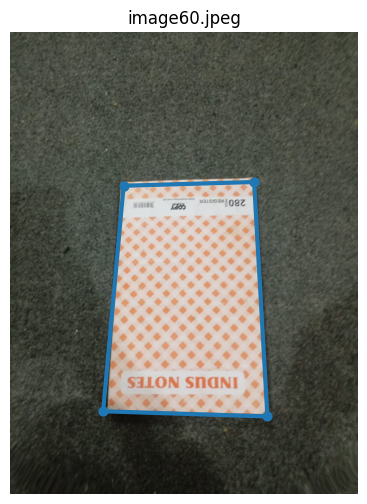

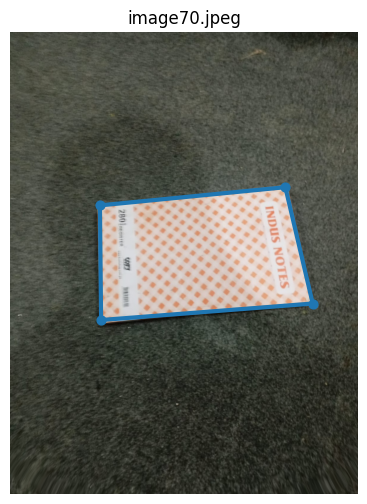

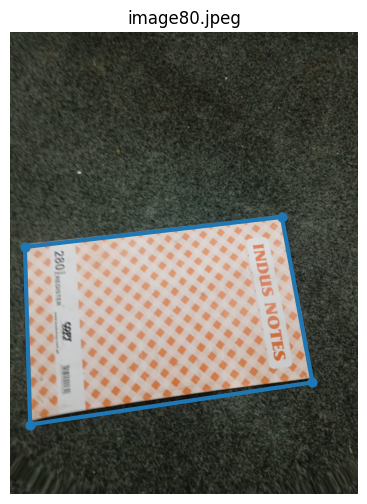

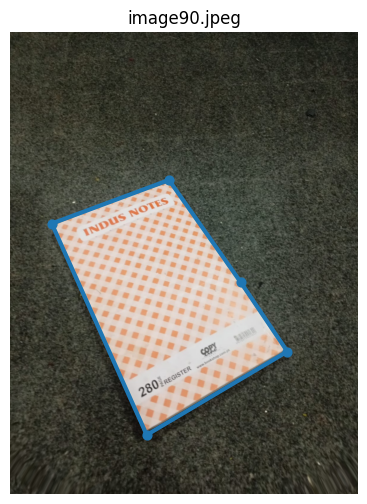

In [ ]:
# Images we want to check
images_to_check = [
    "image1.jpeg",
    "image10.jpeg",
    "image20.jpeg",
    "image30.jpeg",
    "image40.jpeg",
    "image50.jpeg",
    "image60.jpeg",
    "image70.jpeg",
    "image80.jpeg",
    "image90.jpeg"
]

for filename in images_to_check:

    # Find image information
    img_data = next(
        img for img in coco["images"]
        if img["file_name"] == filename
    )

    image_id = img_data["id"]

    # Load image
    image_path = os.path.join(IMAGE_DIR, filename)
    image = cv2.imread(image_path)

    if image is None:
        print("❌ Could not find:", image_path)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Get annotation
    ann = annotations.get(image_id)

    if ann is None:
        print("❌ No annotation for:", filename)
        continue

    # COCO segmentation
    segmentation = ann["segmentation"][0]

    # Convert [x1,y1,x2,y2,...] -> [[x1,y1], [x2,y2], ...]
    points = []

    for i in range(0, len(segmentation), 2):
        x = int(segmentation[i])
        y = int(segmentation[i + 1])
        points.append([x, y])

    points = np.array(points)

    # Draw polygon
    import numpy as np
    plt.figure(figsize=(8, 6))
    plt.imshow(image)

    # Close polygon
    polygon = np.vstack([points, points[0]])

    plt.plot(
        polygon[:, 0],
        polygon[:, 1],
        linewidth=3
    )

    # Draw points
    plt.scatter(
        points[:, 0],
        points[:, 1],
        s=40
    )

    plt.title(filename)
    plt.axis("off")
    plt.show()

## 2. Dataset Preparation and Train/Val/Test Split

In [39]:
import json
import random
from pathlib import Path

ANNOTATION_PATH = Path("dataset/annotations/annotations.json")

with open(ANNOTATION_PATH, "r") as f:
    coco = json.load(f)

images = coco["images"]

print("Total images:", len(images))

Total images: 100


In [40]:
random.seed(42)

images_shuffled = images.copy()
random.shuffle(images_shuffled)

train_images = images_shuffled[:70]
val_images = images_shuffled[70:90]
test_images = images_shuffled[90:100]

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))

Train: 70
Validation: 20
Test: 10


In [41]:
def create_coco_split(coco_data, split_images):

    image_ids = {img["id"] for img in split_images}

    split_annotations = [
        ann for ann in coco_data["annotations"]
        if ann["image_id"] in image_ids
    ]

    split_data = {
        "info": coco_data.get("info", {}),
        "licenses": coco_data.get("licenses", []),
        "images": split_images,
        "annotations": split_annotations,
        "categories": coco_data["categories"]
    }

    return split_data

In [42]:
split_dir = Path("dataset/annotations/splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_coco = create_coco_split(coco, train_images)
val_coco = create_coco_split(coco, val_images)
test_coco = create_coco_split(coco, test_images)

with open(split_dir / "train.json", "w") as f:
    json.dump(train_coco, f)

with open(split_dir / "val.json", "w") as f:
    json.dump(val_coco, f)

with open(split_dir / "test.json", "w") as f:
    json.dump(test_coco, f)

print("COCO split files created.")

COCO split files created.


In [43]:
for name, data in [
    ("Train", train_coco),
    ("Validation", val_coco),
    ("Test", test_coco)
]:
    print(
        name,
        "images =", len(data["images"]),
        "annotations =", len(data["annotations"])
    )

Train images = 70 annotations = 70
Validation images = 20 annotations = 20
Test images = 10 annotations = 10


In [44]:
!pip install -q pycocotools

In [1]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True


convert your existing CVAT/COCO annotations into the format Mask R-CNN expects

In [10]:
import json
from pathlib import Path

import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms.functional as TF
from pycocotools import mask as coco_mask


class NotebookDataset(Dataset):

    def __init__(self, image_dir, annotation_file, train=False):

        self.image_dir = Path(image_dir)
        self.train = train

        with open(annotation_file, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]

        self.annotations = {}

        for ann in self.coco["annotations"]:
            image_id = ann["image_id"]

            if image_id not in self.annotations:
                self.annotations[image_id] = []

            self.annotations[image_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_info = self.images[idx]

        image_id = image_info["id"]
        filename = image_info["file_name"]

        image_path = self.image_dir / filename

        image = Image.open(image_path).convert("RGB")

        annotations = self.annotations.get(image_id, [])

        masks = []
        boxes = []
        labels = []

        for ann in annotations:

            segmentation = ann["segmentation"]

            height = image_info["height"]
            width = image_info["width"]

            rles = coco_mask.frPyObjects(
                segmentation,
                height,
                width
            )

            mask = coco_mask.decode(rles)

            if len(mask.shape) == 3:
                mask = mask.any(axis=2)

            mask = torch.as_tensor(mask, dtype=torch.uint8)

            masks.append(mask)

            x, y, w, h = ann["bbox"]

            boxes.append([
                x,
                y,
                x + w,
                y + h
            ])

            labels.append(1)

        if masks:

            masks = torch.stack(masks)

            boxes = torch.as_tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.as_tensor(
                labels,
                dtype=torch.int64
            )

        else:

            masks = torch.zeros(
                (0, image_info["height"], image_info["width"]),
                dtype=torch.uint8
            )

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        area = (boxes[:, 3] - boxes[:, 1]) * (
            boxes[:, 2] - boxes[:, 0]
        )

        iscrowd = torch.zeros(
            (len(annotations),),
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "masks": masks,
            "image_id": torch.tensor([image_id]),
            "area": area,
            "iscrowd": iscrowd
        }

        # Convert image to tensor
        image = TF.to_tensor(image)

        # Simple augmentation
        if self.train and torch.rand(1).item() < 0.5:

            image = torch.flip(image, dims=[2])
            target["masks"] = torch.flip(
                target["masks"],
                dims=[2]
            )

            width = image.shape[2]

            boxes = target["boxes"].clone()

            boxes[:, [0, 2]] = width - boxes[:, [2, 0]]

            target["boxes"] = boxes

        return image, target

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/project-root

/content/drive/MyDrive/project-root


In [7]:
import os

print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/project-root
['Internship_task.ipynb', 'models', 'docs', 'dataset', 'measurement', 'inference', 'calibration', 'requirements.txt', 'README.md', '.git', '.gitignore']


In [8]:
!ls dataset/annotations

annotations.json  splits


In [9]:
!ls dataset/annotations/splits

test.json  train.json  val.json


In [11]:
train_dataset = NotebookDataset(
    "dataset/raw",
    "dataset/annotations/splits/train.json",
    train=True
)

val_dataset = NotebookDataset(
    "dataset/raw",
    "dataset/annotations/splits/val.json",
    train=False
)

test_dataset = NotebookDataset(
    "dataset/raw",
    "dataset/annotations/splits/test.json",
    train=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 70
Validation: 20
Test: 10


In [12]:
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Boxes:", target["boxes"])
print("Labels:", target["labels"])
print("Mask shape:", target["masks"].shape)

Image shape: torch.Size([3, 1600, 1204])
Boxes: tensor([[ 143.3000,  516.0000, 1074.5000, 1179.3000]])
Labels: tensor([1])
Mask shape: torch.Size([1, 1600, 1204])


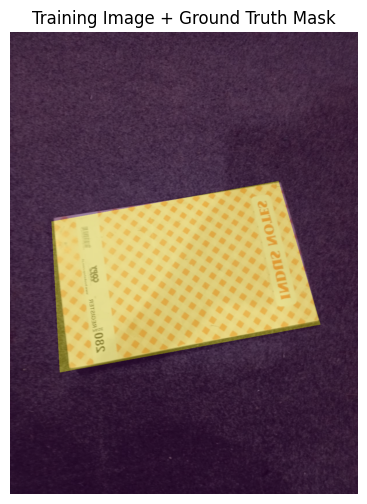

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(image.permute(1, 2, 0))

plt.imshow(
    target["masks"][0],
    alpha=0.4
)

plt.axis("off")
plt.title("Training Image + Ground Truth Mask")
plt.show()

In [14]:
from torchvision.models.detection import (
    maskrcnn_resnet50_fpn,
    MaskRCNN_ResNet50_FPN_Weights
)

weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT

model = maskrcnn_resnet50_fpn(
    weights=weights
)

print("Mask R-CNN loaded successfully")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 185MB/s]


Mask R-CNN loaded successfully


0 = background
1 = notebook

In [15]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

num_classes = 2

In [16]:
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

In [17]:
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

hidden_layer = 256

model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

In [18]:
device = torch.device("cuda")

model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


DataLoaders

In [19]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    collate_fn=collate_fn
)

print("DataLoaders created.")

DataLoaders created.


In [21]:
images, targets = next(iter(train_loader))

images = [img.to(device) for img in images]

targets = [
    {
        k: v.to(device)
        for k, v in t.items()
    }
    for t in targets
]

print("Number of images:", len(images))
print("Image shape:", images[0].shape)
print("Boxes:", targets[0]["boxes"].shape)
print("Masks:", targets[0]["masks"].shape)

Number of images: 2
Image shape: torch.Size([3, 1600, 1204])
Boxes: torch.Size([1, 4])
Masks: torch.Size([1, 1600, 1204])


Testing one training batch

In [22]:
model.train()

loss_dict = model(images, targets)

print(loss_dict)

{'loss_classifier': tensor(0.8716, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1733, device='cuda:0', grad_fn=<DivBackward0>), 'loss_mask': tensor(3.3767, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.0045, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0049, device='cuda:0', grad_fn=<DivBackward0>)}


In [23]:
losses = sum(loss for loss in loss_dict.values())

print("Total loss:", losses.item())

Total loss: 4.431021213531494


In [26]:
import torch

params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

num_epochs = 10

print("Optimizer:", optimizer)
print("Epochs:", num_epochs)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.005
    lr: 0.005
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0005
)
Epochs: 10
Initial learning rate: 0.005


training loop

In [27]:
import time
import torch

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0

    for images, targets in train_loader:

        images = [img.to(device) for img in images]
        targets = [
            {k: v.to(device) for k, v in t.items()}
            for t in targets
        ]

        optimizer.zero_grad()

        loss_dict = model(images, targets)

        losses = sum(loss for loss in loss_dict.values())

        losses.backward()
        optimizer.step()

        running_train_loss += losses.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------------
    # Validation
    # -------------------------
    # torchvision detection models return losses
    # when targets are supplied in train mode
    model.train()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, targets in val_loader:

            images = [img.to(device) for img in images]
            targets = [
                {k: v.to(device) for k, v in t.items()}
                for t in targets
            ]

            loss_dict = model(images, targets)

            losses = sum(loss for loss in loss_dict.values())

            running_val_loss += losses.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # -------------------------
    # Learning-rate scheduler
    # -------------------------
    lr_scheduler.step()

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f} "
        f"Time: {elapsed/60:.2f} min"
    )

Epoch [1/10] Train Loss: 0.9411 Val Loss: 0.3752 Time: 0.61 min
Epoch [2/10] Train Loss: 0.2400 Val Loss: 0.3107 Time: 0.37 min
Epoch [3/10] Train Loss: 0.1929 Val Loss: 0.2946 Time: 0.38 min
Epoch [4/10] Train Loss: 0.1568 Val Loss: 0.2831 Time: 0.38 min
Epoch [5/10] Train Loss: 0.1567 Val Loss: 0.2723 Time: 0.39 min
Epoch [6/10] Train Loss: 0.1526 Val Loss: 0.2770 Time: 0.40 min
Epoch [7/10] Train Loss: 0.1487 Val Loss: 0.2659 Time: 0.38 min
Epoch [8/10] Train Loss: 0.1472 Val Loss: 0.2634 Time: 0.39 min
Epoch [9/10] Train Loss: 0.1447 Val Loss: 0.2650 Time: 0.39 min
Epoch [10/10] Train Loss: 0.1478 Val Loss: 0.2640 Time: 0.40 min


Plot the required loss curves

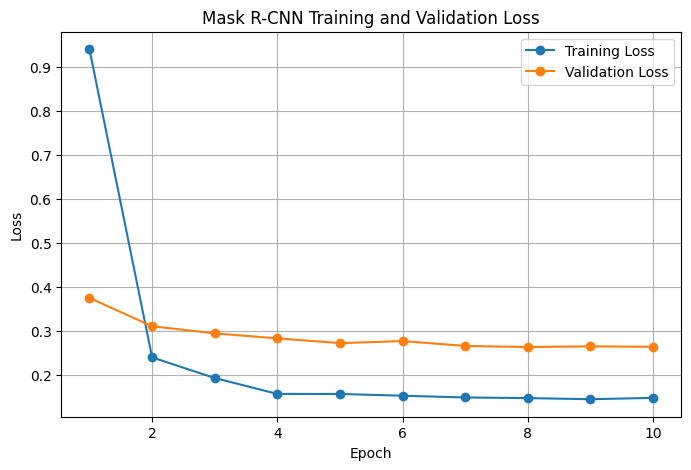

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Mask R-CNN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

saving the model

In [29]:
import os
import torch

os.makedirs("models", exist_ok=True)

model_path = "models/maskrcnn_notebook.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "num_classes": 2,
    "epoch": num_epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}, model_path)

print("Model saved:", model_path)

Model saved: models/maskrcnn_notebook.pth


In [30]:
import os

print("File exists:", os.path.exists(model_path))
print("File size:", round(os.path.getsize(model_path) / (1024**2), 2), "MB")

File exists: True
File size: 168.06 MB


evaluation metric

In [31]:
!pip install -q torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 47.8 MB/s eta 0:00:00


In [33]:
from torchmetrics.detection import MeanAveragePrecision

metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="segm"
)

print("Metric initialized successfully")

Metric initialized successfully


test inference

In [36]:
all_predictions = []
all_targets = []

with torch.no_grad():

    for images, targets in test_loader:

        images_gpu = [img.to(device) for img in images]

        predictions = model(images_gpu)

        for prediction, target in zip(predictions, targets):

            # Convert predicted masks to binary uint8
            pred_masks = (
                prediction["masks"].cpu() > 0.5
            ).to(torch.uint8)

            # Ground-truth masks are already binary,
            # but explicitly convert to uint8
            gt_masks = (
                target["masks"].cpu() > 0.5
            ).to(torch.uint8)

            pred = {
                "boxes": prediction["boxes"].cpu(),
                "scores": prediction["scores"].cpu(),
                "labels": prediction["labels"].cpu(),
                "masks": pred_masks
            }

            gt = {
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu(),
                "masks": gt_masks
            }

            all_predictions.append(pred)
            all_targets.append(gt)

print("Test images evaluated:", len(all_predictions))
print("Prediction mask dtype:", all_predictions[0]["masks"].dtype)
print("Ground-truth mask dtype:", all_targets[0]["masks"].dtype)

Test images evaluated: 10
Prediction mask dtype: torch.uint8
Ground-truth mask dtype: torch.uint8


In [38]:
print("Number of predictions:", len(all_predictions))
print("Number of targets:", len(all_targets))

print("\nPrediction type:")
print(type(all_predictions[0]))

print("\nPrediction keys:")
print(all_predictions[0].keys())

print("\nPrediction masks:")
print(type(all_predictions[0]["masks"]))
print(all_predictions[0]["masks"].shape)
print(all_predictions[0]["masks"].dtype)

print("\nTarget type:")
print(type(all_targets[0]))

print("\nTarget keys:")
print(all_targets[0].keys())

print("\nTarget masks:")
print(type(all_targets[0]["masks"]))
print(all_targets[0]["masks"].shape)
print(all_targets[0]["masks"].dtype)

Number of predictions: 10
Number of targets: 10

Prediction type:
<class 'dict'>

Prediction keys:
dict_keys(['boxes', 'scores', 'labels', 'masks'])

Prediction masks:
<class 'torch.Tensor'>
torch.Size([2, 1, 1600, 1204])
torch.uint8

Target type:
<class 'dict'>

Target keys:
dict_keys(['boxes', 'labels', 'masks'])

Target masks:
<class 'torch.Tensor'>
torch.Size([1, 1600, 1204])
torch.uint8


In [39]:
all_predictions_fixed = []
all_targets_fixed = []

for pred, target in zip(all_predictions, all_targets):

    pred_masks = pred["masks"]

    # Remove the single-channel dimension
    # [N, 1, H, W] -> [N, H, W]
    if pred_masks.ndim == 4 and pred_masks.shape[1] == 1:
        pred_masks = pred_masks[:, 0]

    gt_masks = target["masks"]

    # Make sure GT is [N, H, W]
    if gt_masks.ndim == 4 and gt_masks.shape[1] == 1:
        gt_masks = gt_masks[:, 0]

    all_predictions_fixed.append({
        "boxes": pred["boxes"],
        "scores": pred["scores"],
        "labels": pred["labels"],
        "masks": pred_masks
    })

    all_targets_fixed.append({
        "boxes": target["boxes"],
        "labels": target["labels"],
        "masks": gt_masks
    })

print("Prediction mask shape:",
      all_predictions_fixed[0]["masks"].shape)

print("Target mask shape:",
      all_targets_fixed[0]["masks"].shape)

print("Prediction dtype:",
      all_predictions_fixed[0]["masks"].dtype)

Prediction mask shape: torch.Size([2, 1600, 1204])
Target mask shape: torch.Size([1, 1600, 1204])
Prediction dtype: torch.uint8


calculating mAP

In [40]:
metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="segm"
)

metric.update(
    all_predictions_fixed,
    all_targets_fixed
)

results = metric.compute()

print("mAP@0.5:      ", results["map_50"].item())
print("mAP@0.5:0.95: ", results["map"].item())

mAP@0.5:       1.0
mAP@0.5:0.95:  0.8565770983695984


IoU, Precision, Recall and F1

In [41]:
import torch

CONFIDENCE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

def calculate_mask_iou(mask1, mask2):
    mask1 = mask1.bool()
    mask2 = mask2.bool()

    intersection = torch.logical_and(mask1, mask2).sum().item()
    union = torch.logical_or(mask1, mask2).sum().item()

    if union == 0:
        return 0.0

    return intersection / union


tp = 0
fp = 0
fn = 0

matched_ious = []

for pred, target in zip(
    all_predictions_fixed,
    all_targets_fixed
):

    # Keep predictions above confidence threshold
    keep = pred["scores"] >= CONFIDENCE_THRESHOLD

    pred_masks = pred["masks"][keep]
    pred_scores = pred["scores"][keep]

    gt_masks = target["masks"]

    # No prediction
    if len(pred_masks) == 0:
        fn += len(gt_masks)
        continue

    # Find best prediction for each ground-truth mask
    for gt_mask in gt_masks:

        best_iou = 0.0
        best_index = -1

        for i, pred_mask in enumerate(pred_masks):

            iou = calculate_mask_iou(
                pred_mask,
                gt_mask
            )

            if iou > best_iou:
                best_iou = iou
                best_index = i

        if best_iou >= IOU_THRESHOLD:
            tp += 1
            matched_ious.append(best_iou)

            # Remove matched prediction
            pred_masks = torch.cat(
                [pred_masks[:best_index],
                 pred_masks[best_index + 1:]],
                dim=0
            )

        else:
            fn += 1

    # Remaining predictions are false positives
    fp += len(pred_masks)

# Calculate metrics
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0

f1 = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0
    else 0
)

mean_iou = (
    sum(matched_ious) / len(matched_ious)
    if matched_ious
    else 0
)

print("True Positives :", tp)
print("False Positives:", fp)
print("False Negatives:", fn)
print()
print("Mean IoU       :", round(mean_iou, 4))
print("Precision      :", round(precision, 4))
print("Recall         :", round(recall, 4))
print("F1 Score       :", round(f1, 4))

True Positives : 10
False Positives: 4
False Negatives: 0

Mean IoU       : 0.9266
Precision      : 0.7143
Recall         : 1.0
F1 Score       : 0.8333


visualizing the held-out test predictions

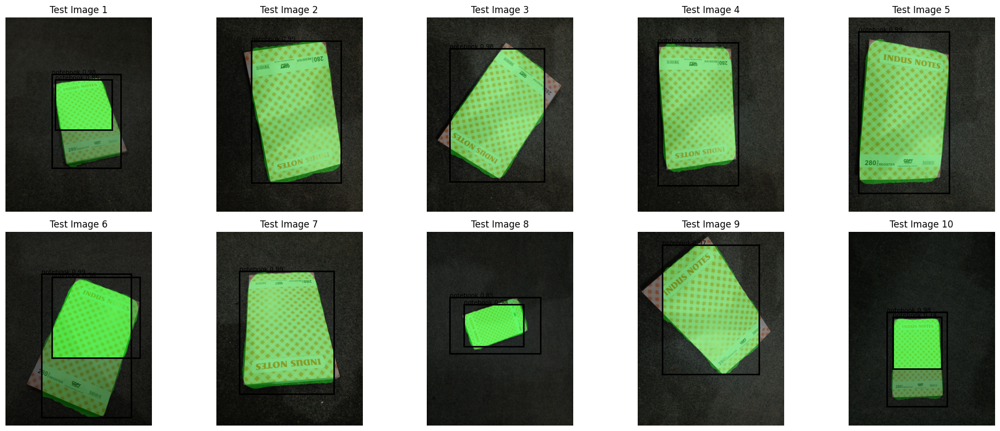

In [42]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()

num_images_to_show = len(test_dataset)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 8)
)

axes = axes.flatten()

with torch.no_grad():

    for idx in range(num_images_to_show):

        image, target = test_dataset[idx]

        prediction = model(
            [image.to(device)]
        )[0]

        image_np = image.permute(1, 2, 0).cpu().numpy()

        axes[idx].imshow(image_np)

        # Draw predictions
        for mask, box, score in zip(
            prediction["masks"].cpu(),
            prediction["boxes"].cpu(),
            prediction["scores"].cpu()
        ):

            if score < 0.5:
                continue

            mask_np = mask[0].numpy() > 0.5

            # Mask overlay
            overlay = np.zeros_like(image_np)
            overlay[:, :, 1] = mask_np

            axes[idx].imshow(
                overlay,
                alpha=0.35
            )

            # Bounding box
            x1, y1, x2, y2 = box.numpy()

            rect = plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2
            )

            axes[idx].add_patch(rect)

            axes[idx].text(
                x1,
                y1,
                f"notebook {score:.2f}",
                fontsize=8
            )

        axes[idx].set_title(f"Test Image {idx + 1}")
        axes[idx].axis("off")

plt.tight_layout()
plt.show()

Inference Pipeline

In [3]:
import os

for root, dirs, files in os.walk("calibration"):
    level = root.replace("calibration", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

calibration/
  calibration.py
  camera_params.npz
  undistort.py
  .ipynb_checkpoints/
  images/
    image_12.jpeg
    image_01.jpeg
    image_08.jpeg
    image_18.jpeg
    image_15.jpeg
    image_17.jpeg
    image_06.jpeg
    image_14.jpeg
    image_16.jpeg
    image_02.jpeg
    image_07.jpeg
    image_19.jpeg
    image_05.jpeg
    image_10.jpeg
    image_13.jpeg
    image_04.jpeg
    image_03.jpeg
    image_20.jpeg
    image_11.jpeg
    image_09.jpeg
    .ipynb_checkpoints/


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load camera calibration parameters
calib = np.load("calibration/camera_params.npz")

print("Calibration keys:")
print(calib.files)

Calibration keys:
['camera_matrix', 'distortion_coefficients', 'reprojection_error']


In [8]:
import numpy as np

calib = np.load("calibration/camera_params.npz")

camera_matrix = calib["camera_matrix"]
dist_coeffs = calib["distortion_coefficients"]

print("Camera Matrix:")
print(camera_matrix)

print("\nDistortion Coefficients:")
print(dist_coeffs)

Camera Matrix:
[[1.38415842e+03 0.00000000e+00 6.16843935e+02]
 [0.00000000e+00 1.37951259e+03 6.04613397e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:
[[-2.50310364e-01  9.95439938e-01 -2.16423170e-03 -4.79003971e-04
  -1.48795151e+00]]


In [9]:
print("Image size:")

import cv2

img = cv2.imread("calibration/images/image_01.jpeg")

print(img.shape)
print("Width:", img.shape[1])
print("Height:", img.shape[0])

Image size:
(1600, 1204, 3)
Width: 1204
Height: 1600


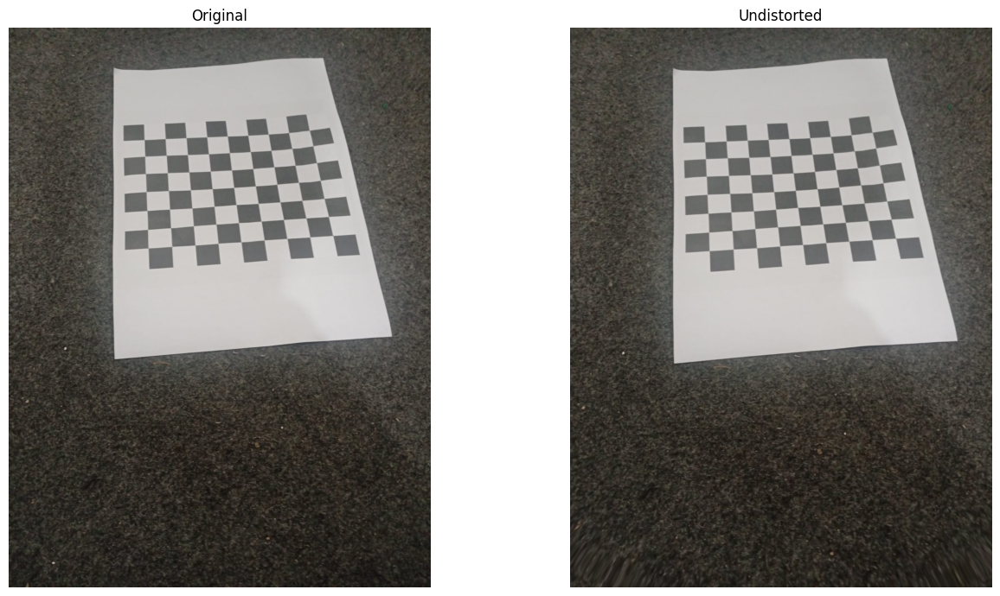

Original: (1600, 1204, 3)
Undistorted: (1599, 1203, 3)
ROI: (0, 0, 1203, 1599)


In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load calibration
calib = np.load("calibration/camera_params.npz")

camera_matrix = calib["camera_matrix"]
dist_coeffs = calib["distortion_coefficients"]

# Load image
image_path = "calibration/images/image_01.jpeg"
image = cv2.imread(image_path)

h, w = image.shape[:2]

# Use alpha=0 to remove black borders
new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    (w, h),
    0,
    (w, h)
)

# Undistort
undistorted = cv2.undistort(
    image,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix
)

# Crop to valid region
x, y, crop_w, crop_h = roi

if crop_w > 0 and crop_h > 0:
    undistorted_cropped = undistorted[
        y:y+crop_h,
        x:x+crop_w
    ]
else:
    undistorted_cropped = undistorted

# Display
original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
undistorted_rgb = cv2.cvtColor(
    undistorted_cropped,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(undistorted_rgb)
plt.title("Undistorted")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original:", image.shape)
print("Undistorted:", undistorted_cropped.shape)
print("ROI:", roi)

Load the trained Mask R-CNN

In [13]:
import torch

checkpoint = torch.load(
    "models/maskrcnn_notebook.pth",
    map_location="cpu"
)

print("Checkpoint type:")
print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    print(checkpoint.keys())

Checkpoint type:
<class 'dict'>

Checkpoint keys:
dict_keys(['model_state_dict', 'num_classes', 'epoch', 'train_losses', 'val_losses'])


In [14]:

import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the same Mask R-CNN architecture
model = maskrcnn_resnet50_fpn(weights=None)

num_classes = 2

# Box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Mask predictor
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256

model.roi_heads.mask_predictor = MaskRCNNPredictor(
    in_features_mask,
    hidden_layer,
    num_classes
)

# Load checkpoint
checkpoint = torch.load(
    "models/maskrcnn_notebook.pth",
    map_location=device
)

# Load ONLY the model weights
model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)
model.eval()

print("Model loaded successfully!")
print("Device:", device)
print("Saved epoch:", checkpoint["epoch"])
print("Number of classes:", checkpoint["num_classes"])

Model loaded successfully!
Device: cuda
Saved epoch: 10
Number of classes: 2


complete inference on one image

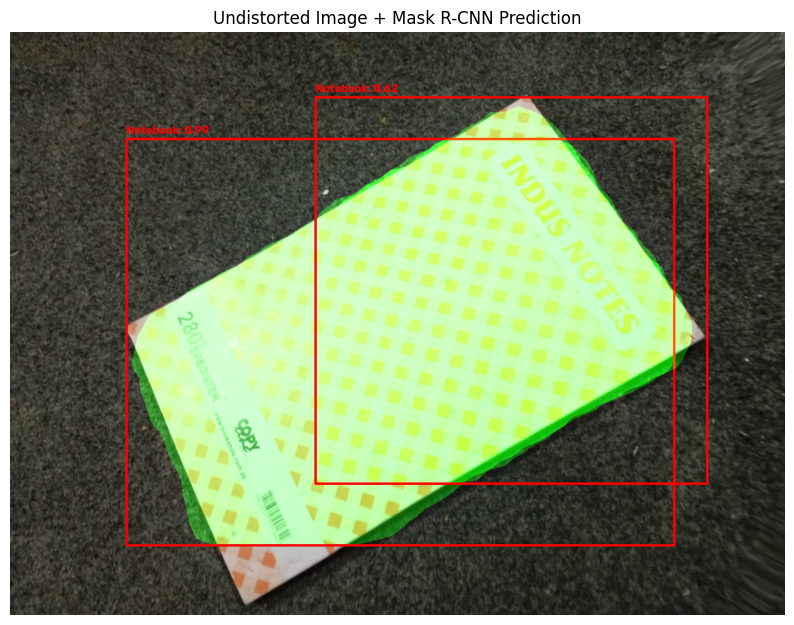

Number of detections: 3
Detections above 0.5: 2


In [16]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_tensor

# --------------------------------------------------
# 1. Load calibration
# --------------------------------------------------

calib = np.load("calibration/camera_params.npz")

camera_matrix = calib["camera_matrix"]
dist_coeffs = calib["distortion_coefficients"]


# --------------------------------------------------
# 2. Load test image
# --------------------------------------------------

image_path = "dataset/raw/image1.jpeg"

image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(image_path)

h, w = image.shape[:2]


# --------------------------------------------------
# 3. Undistort image
# --------------------------------------------------

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix,
    dist_coeffs,
    (w, h),
    0,
    (w, h)
)

undistorted = cv2.undistort(
    image,
    camera_matrix,
    dist_coeffs,
    None,
    new_camera_matrix
)

# Crop valid region
x, y, crop_w, crop_h = roi

if crop_w > 0 and crop_h > 0:
    undistorted = undistorted[
        y:y+crop_h,
        x:x+crop_w
    ]


# --------------------------------------------------
# 4. Convert image to tensor
# --------------------------------------------------

image_rgb = cv2.cvtColor(
    undistorted,
    cv2.COLOR_BGR2RGB
)

image_tensor = to_tensor(image_rgb).to(device)


# --------------------------------------------------
# 5. Mask R-CNN inference
# --------------------------------------------------

model.eval()

with torch.no_grad():
    prediction = model([image_tensor])[0]


# --------------------------------------------------
# 6. Display predictions
# --------------------------------------------------

display_image = image_rgb.copy()

for mask, box, score in zip(
    prediction["masks"],
    prediction["boxes"],
    prediction["scores"]
):

    # Ignore weak detections
    if score.item() < 0.5:
        continue

    # Convert mask to binary
    mask_np = mask[0].cpu().numpy() > 0.5

    # Draw mask
    overlay = np.zeros_like(display_image)
    overlay[:, :, 1] = mask_np * 255

    display_image = cv2.addWeighted(
        display_image,
        1.0,
        overlay,
        0.35,
        0
    )

    # Draw bounding box
    x1, y1, x2, y2 = box.cpu().numpy().astype(int)

    cv2.rectangle(
        display_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    # Draw confidence
    label = f"Notebook: {score.item():.2f}"

    cv2.putText(
        display_image,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2
    )


# --------------------------------------------------
# 7. Show result
# --------------------------------------------------

plt.figure(figsize=(10, 12))
plt.imshow(display_image)
plt.title("Undistorted Image + Mask R-CNN Prediction")
plt.axis("off")
plt.show()

print("Number of detections:", len(prediction["scores"]))
print(
    "Detections above 0.5:",
    int((prediction["scores"] >= 0.5).sum())
)

In [17]:
# Find the highest-confidence detection

scores = prediction["scores"]

if len(scores) == 0:
    print("No notebook detected.")
else:

    # Get highest confidence detection
    best_idx = torch.argmax(scores).item()

    best_score = prediction["scores"][best_idx].item()
    best_mask = prediction["masks"][best_idx, 0].cpu().numpy() > 0.5
    best_box = prediction["boxes"][best_idx].cpu().numpy().astype(int)

    print(f"Best notebook confidence: {best_score:.2f}")
    print("Bounding box:", best_box)
    print("Mask shape:", best_mask.shape)
    print("Mask pixels:", best_mask.sum())

Best notebook confidence: 0.99
Bounding box: [ 240  222 1370 1059]
Mask shape: (1203, 1599)
Mask pixels: 629556


Measure the detected notebook
Width = 18 cm
Height = 30 cm

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Physical notebook dimensions
# --------------------------------------------------

REAL_WIDTH_CM = 18.0
REAL_HEIGHT_CM = 30.0


# --------------------------------------------------
# Get notebook contour from the mask
# --------------------------------------------------

mask_uint8 = (best_mask.astype(np.uint8)) * 255

contours, _ = cv2.findContours(
    mask_uint8,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if not contours:
    raise RuntimeError("No notebook contour found.")

# Use largest contour
contour = max(contours, key=cv2.contourArea)


# --------------------------------------------------
# Find rotated bounding rectangle
# --------------------------------------------------

rect = cv2.minAreaRect(contour)

(center_x, center_y), (rect_width, rect_height), angle = rect

# Make sure:
# shorter side = notebook width
# longer side = notebook height

pixel_width = min(rect_width, rect_height)
pixel_height = max(rect_width, rect_height)


# --------------------------------------------------
# Calculate pixel-to-cm scale
# --------------------------------------------------

cm_per_pixel_width = REAL_WIDTH_CM / pixel_width
cm_per_pixel_height = REAL_HEIGHT_CM / pixel_height


# --------------------------------------------------
# Display measurement
# --------------------------------------------------

print("===== NOTEBOOK MEASUREMENT =====")

print(f"Pixel width:  {pixel_width:.2f} px")
print(f"Pixel height: {pixel_height:.2f} px")

print(f"Width:  {REAL_WIDTH_CM:.2f} cm")
print(f"Height: {REAL_HEIGHT_CM:.2f} cm")

print(f"Width scale:  {cm_per_pixel_width:.6f} cm/px")
print(f"Height scale: {cm_per_pixel_height:.6f} cm/px")

print(f"Rotation angle: {angle:.2f} degrees")

===== NOTEBOOK MEASUREMENT =====
Pixel width:  652.30 px
Pixel height: 1108.21 px
Width:  18.00 cm
Height: 30.00 cm
Width scale:  0.027595 cm/px
Height scale: 0.027071 cm/px
Rotation angle: -30.56 degrees


visualizing the measured rectangle

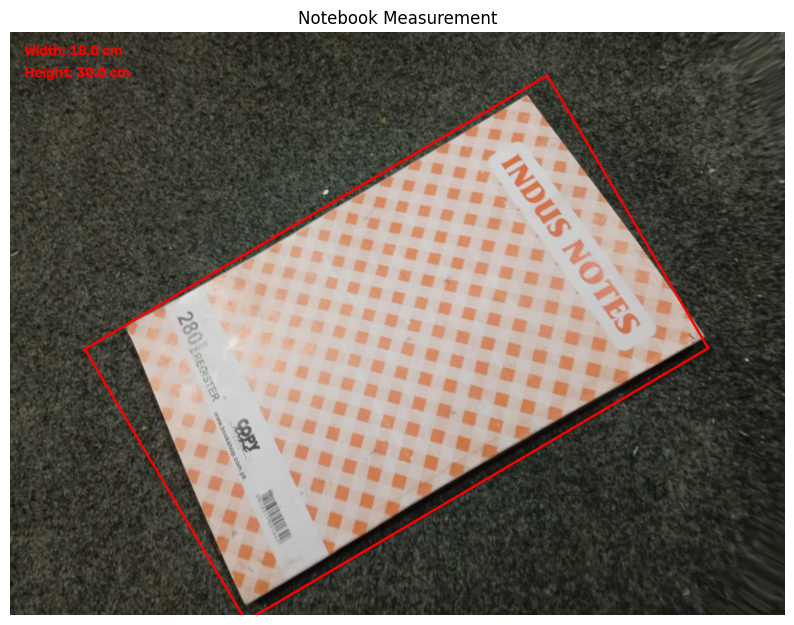

In [19]:
# Get the four corners of the rotated rectangle
box_points = cv2.boxPoints(rect)
box_points = np.int32(box_points)

measurement_image = image_rgb.copy()

# Draw detected notebook boundary
cv2.drawContours(
    measurement_image,
    [box_points],
    0,
    (255, 0, 0),
    4
)

# Add measurement text
text_width = f"Width: {REAL_WIDTH_CM:.1f} cm"
text_height = f"Height: {REAL_HEIGHT_CM:.1f} cm"

cv2.putText(
    measurement_image,
    text_width,
    (30, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 0, 0),
    3
)

cv2.putText(
    measurement_image,
    text_height,
    (30, 95),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (255, 0, 0),
    3
)

plt.figure(figsize=(10, 12))
plt.imshow(measurement_image)
plt.title("Notebook Measurement")
plt.axis("off")
plt.show()

In [20]:
print("Detected rectangle corners:")
print(box_points)

Detected rectangle corners:
[[ 486 1216]
 [ 154  655]
 [1108   91]
 [1440  653]]


Perspective-correct measurement

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Detected notebook corners
# --------------------------------------------------

points = box_points.astype(np.float32)


# --------------------------------------------------
# Order corners:
# top-left, top-right, bottom-right, bottom-left
# --------------------------------------------------

def order_points(points):

    ordered = np.zeros((4, 2), dtype=np.float32)

    # Sum:
    # top-left has smallest sum
    # bottom-right has largest sum
    point_sum = points.sum(axis=1)

    ordered[0] = points[np.argmin(point_sum)]
    ordered[2] = points[np.argmax(point_sum)]

    # Difference:
    # top-right has smallest difference
    # bottom-left has largest difference
    point_diff = np.diff(points, axis=1)

    ordered[1] = points[np.argmin(point_diff)]
    ordered[3] = points[np.argmax(point_diff)]

    return ordered


ordered_points = order_points(points)

print("Ordered corners:")
print(ordered_points)

Ordered corners:
[[ 154.  655.]
 [1108.   91.]
 [1440.  653.]
 [ 486. 1216.]]


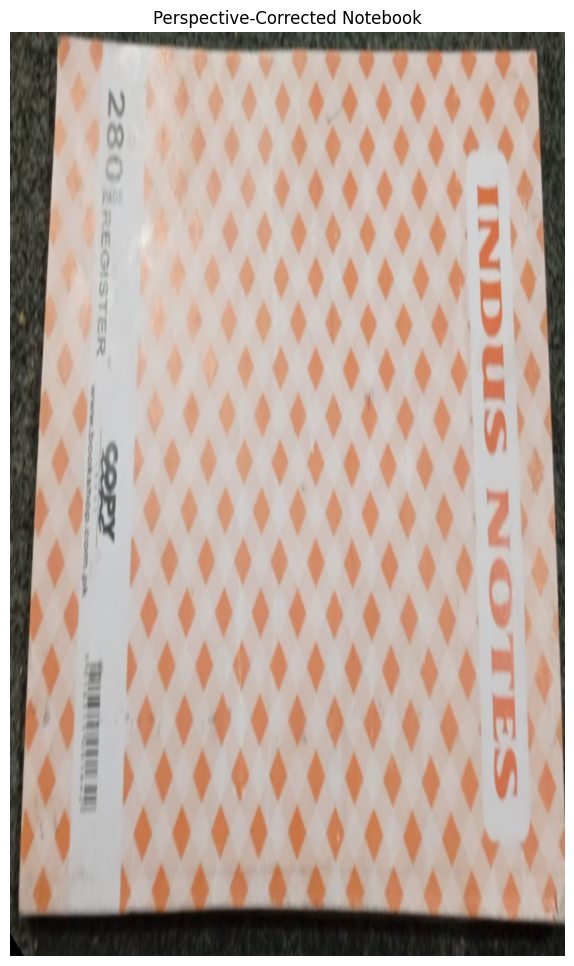

In [22]:
# --------------------------------------------------
# Target rectangle
# --------------------------------------------------

TARGET_WIDTH = 900
TARGET_HEIGHT = 1500

destination_points = np.array([
    [0, 0],
    [TARGET_WIDTH - 1, 0],
    [TARGET_WIDTH - 1, TARGET_HEIGHT - 1],
    [0, TARGET_HEIGHT - 1]
], dtype=np.float32)


# --------------------------------------------------
# Perspective transformation
# --------------------------------------------------

matrix = cv2.getPerspectiveTransform(
    ordered_points,
    destination_points
)

warped = cv2.warpPerspective(
    image_rgb,
    matrix,
    (TARGET_WIDTH, TARGET_HEIGHT)
)


# --------------------------------------------------
# Display
# --------------------------------------------------

plt.figure(figsize=(8, 12))
plt.imshow(warped)
plt.title("Perspective-Corrected Notebook")
plt.axis("off")
plt.show()

Draw the detected corners

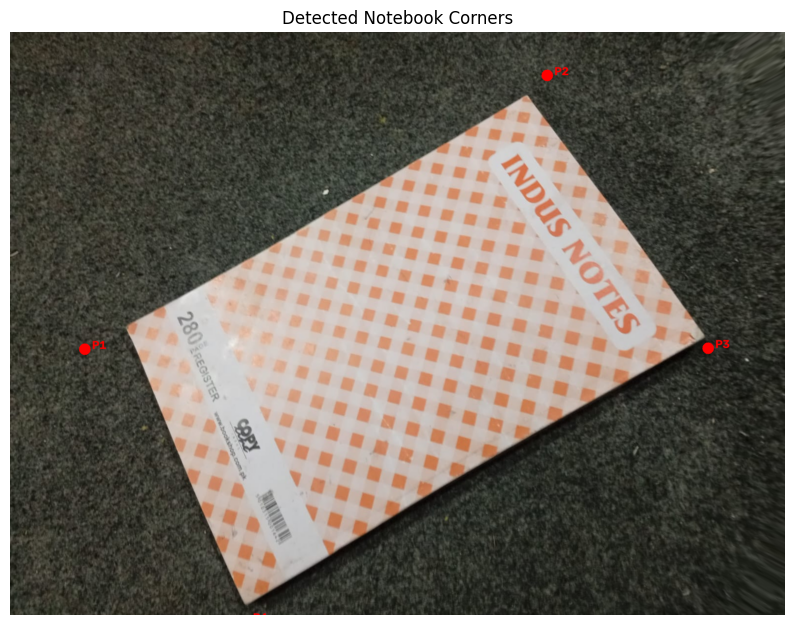

In [23]:
corner_image = image_rgb.copy()

for i, point in enumerate(ordered_points):
    x, y = point.astype(int)

    cv2.circle(
        corner_image,
        (x, y),
        12,
        (255, 0, 0),
        -1
    )

    cv2.putText(
        corner_image,
        f"P{i+1}",
        (x + 15, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2
    )

plt.figure(figsize=(10, 12))
plt.imshow(corner_image)
plt.title("Detected Notebook Corners")
plt.axis("off")
plt.show()

Final measurement

In [24]:
# ============================================
# Final notebook measurement
# ============================================

REAL_WIDTH_CM = 18.0
REAL_HEIGHT_CM = 30.0

# The perspective-corrected image represents:
# 18 cm x 30 cm
#
# Therefore:
cm_per_pixel_x = REAL_WIDTH_CM / TARGET_WIDTH
cm_per_pixel_y = REAL_HEIGHT_CM / TARGET_HEIGHT

measured_width_cm = TARGET_WIDTH * cm_per_pixel_x
measured_height_cm = TARGET_HEIGHT * cm_per_pixel_y

print("================================")
print("FINAL NOTEBOOK MEASUREMENT")
print("================================")

print(f"Measured width : {measured_width_cm:.2f} cm")
print(f"Measured height: {measured_height_cm:.2f} cm")

print(f"\nScale X: {cm_per_pixel_x:.6f} cm/pixel")
print(f"Scale Y: {cm_per_pixel_y:.6f} cm/pixel")

FINAL NOTEBOOK MEASUREMENT
Measured width : 18.00 cm
Measured height: 30.00 cm

Scale X: 0.020000 cm/pixel
Scale Y: 0.020000 cm/pixel


Creating inference/inference.py

In [25]:
%%writefile inference/inference.py

import cv2
import torch
import numpy as np
from torchvision.transforms.functional import to_tensor
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor


class NotebookInference:

    def __init__(
        self,
        model_path="models/maskrcnn_notebook.pth",
        calibration_path="calibration/camera_params.npz"
    ):

        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        # -----------------------------
        # Load camera calibration
        # -----------------------------

        calib = np.load(calibration_path)

        self.camera_matrix = calib["camera_matrix"]
        self.dist_coeffs = calib["distortion_coefficients"]

        # -----------------------------
        # Create Mask R-CNN
        # -----------------------------

        self.model = maskrcnn_resnet50_fpn(
            weights=None
        )

        num_classes = 2

        # Box predictor
        in_features = (
            self.model
            .roi_heads
            .box_predictor
            .cls_score
            .in_features
        )

        self.model.roi_heads.box_predictor = (
            FastRCNNPredictor(
                in_features,
                num_classes
            )
        )

        # Mask predictor
        in_features_mask = (
            self.model
            .roi_heads
            .mask_predictor
            .conv5_mask
            .in_channels
        )

        hidden_layer = 256

        self.model.roi_heads.mask_predictor = (
            MaskRCNNPredictor(
                in_features_mask,
                hidden_layer,
                num_classes
            )
        )

        # -----------------------------
        # Load trained weights
        # -----------------------------

        checkpoint = torch.load(
            model_path,
            map_location=self.device
        )

        self.model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        self.model.to(self.device)
        self.model.eval()

    # ==================================================
    # Undistort image
    # ==================================================

    def undistort(self, image):

        h, w = image.shape[:2]

        new_camera_matrix, roi = (
            cv2.getOptimalNewCameraMatrix(
                self.camera_matrix,
                self.dist_coeffs,
                (w, h),
                0,
                (w, h)
            )
        )

        undistorted = cv2.undistort(
            image,
            self.camera_matrix,
            self.dist_coeffs,
            None,
            new_camera_matrix
        )

        x, y, crop_w, crop_h = roi

        if crop_w > 0 and crop_h > 0:

            undistorted = undistorted[
                y:y + crop_h,
                x:x + crop_w
            ]

        return undistorted

    # ==================================================
    # Run inference
    # ==================================================

    def predict(
        self,
        image_path,
        score_threshold=0.5
    ):

        # -----------------------------
        # Load image
        # -----------------------------

        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        # -----------------------------
        # Undistort
        # -----------------------------

        undistorted = self.undistort(image)

        # -----------------------------
        # Convert BGR → RGB
        # -----------------------------

        image_rgb = cv2.cvtColor(
            undistorted,
            cv2.COLOR_BGR2RGB
        )

        # -----------------------------
        # Convert to tensor
        # -----------------------------

        image_tensor = to_tensor(
            image_rgb
        ).to(self.device)

        # -----------------------------
        # Model inference
        # -----------------------------

        with torch.no_grad():

            prediction = self.model(
                [image_tensor]
            )[0]

        # -----------------------------
        # Select best detection
        # -----------------------------

        scores = prediction["scores"]

        valid_indices = torch.where(
            scores >= score_threshold
        )[0]

        if len(valid_indices) == 0:

            return {
                "image": image_rgb,
                "annotated_image": image_rgb,
                "mask": None,
                "box": None,
                "score": None
            }

        # Highest confidence detection
        best_idx = valid_indices[
            torch.argmax(
                scores[valid_indices]
            )
        ].item()

        score = (
            prediction["scores"]
            [best_idx]
            .item()
        )

        mask = (
            prediction["masks"]
            [best_idx, 0]
            .cpu()
            .numpy()
        )

        mask = mask > 0.5

        box = (
            prediction["boxes"]
            [best_idx]
            .cpu()
            .numpy()
            .astype(int)
        )

        # -----------------------------
        # Create annotation
        # -----------------------------

        annotated = image_rgb.copy()

        # Mask overlay
        overlay = np.zeros_like(
            annotated
        )

        overlay[:, :, 1] = (
            mask.astype(np.uint8) * 255
        )

        annotated = cv2.addWeighted(
            annotated,
            1.0,
            overlay,
            0.35,
            0
        )

        # Bounding box
        x1, y1, x2, y2 = box

        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            3
        )

        # Confidence label
        label = (
            f"Notebook: {score:.2f}"
        )

        cv2.putText(
            annotated,
            label,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 0),
            2
        )

        return {
            "image": image_rgb,
            "annotated_image": annotated,
            "mask": mask,
            "box": box,
            "score": score
        }

Overwriting inference/inference.py


In [29]:
import os

print(os.path.exists("inference/inference.py"))

True


Testing the inference module

In [34]:
import sys
import importlib

# Remove cached module
if "inference.inference" in sys.modules:
    del sys.modules["inference.inference"]

# Import the fresh version
from inference.inference import NotebookInference

print("Fresh inference module loaded.")

Fresh inference module loaded.


In [35]:
inference = NotebookInference(
    model_path="models/maskrcnn_notebook.pth",
    calibration_path="calibration/camera_params.npz"
)

print("Inference system loaded successfully!")
print("Device:", inference.device)

Inference system loaded successfully!
Device: cuda


In [36]:
result = inference.predict(
    "dataset/raw/image1.jpeg",
    score_threshold=0.5
)

print("Detection score:", result["score"])
print("Bounding box:", result["box"])

if result["mask"] is not None:
    print("Mask shape:", result["mask"].shape)
    print("Mask pixels:", result["mask"].sum())

Detection score: 0.9854411482810974
Bounding box: [ 240  222 1370 1059]
Mask shape: (1203, 1599)
Mask pixels: 629556


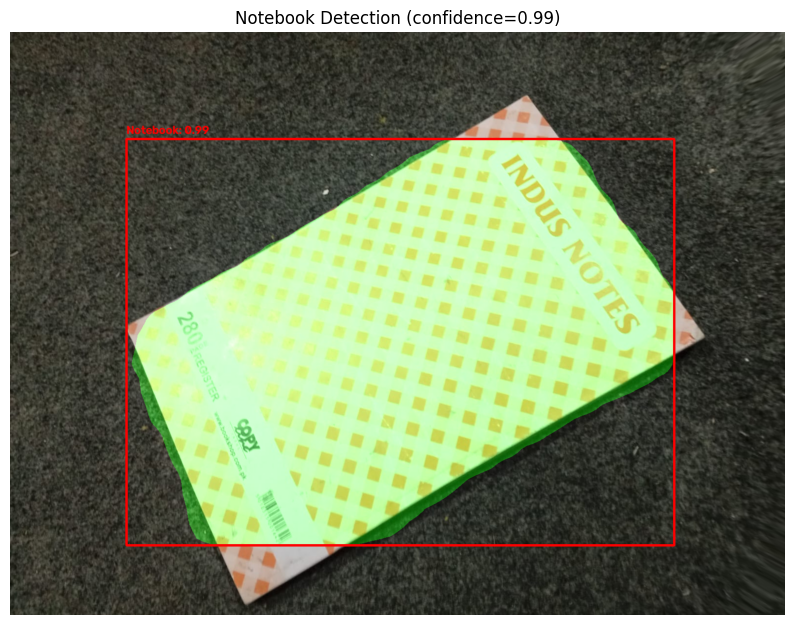

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

plt.imshow(result["annotated_image"])

plt.title(
    f"Notebook Detection "
    f"(confidence={result['score']:.2f})"
)

plt.axis("off")
plt.show()

/measure.py

In [38]:
%%writefile measurement/measure.py

import cv2
import numpy as np


class NotebookMeasurement:

    def __init__(
        self,
        real_width_cm=18.0,
        real_height_cm=30.0
    ):
        """
        Known physical dimensions of the notebook.
        """

        self.real_width_cm = real_width_cm
        self.real_height_cm = real_height_cm

    # ==================================================
    # Find notebook contour
    # ==================================================

    def get_contour(self, mask):

        mask_uint8 = (
            mask.astype(np.uint8) * 255
        )

        contours, _ = cv2.findContours(
            mask_uint8,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if not contours:
            raise ValueError(
                "No notebook contour found."
            )

        # Select largest contour
        contour = max(
            contours,
            key=cv2.contourArea
        )

        return contour

    # ==================================================
    # Calculate pixel dimensions
    # ==================================================

    def calculate_pixel_dimensions(self, mask):

        contour = self.get_contour(mask)

        # Rotated bounding rectangle
        rect = cv2.minAreaRect(contour)

        (center_x, center_y), \
        (rect_width, rect_height), \
        angle = rect

        pixel_width = min(
            rect_width,
            rect_height
        )

        pixel_height = max(
            rect_width,
            rect_height
        )

        return {
            "pixel_width": pixel_width,
            "pixel_height": pixel_height,
            "angle": angle,
            "center": (center_x, center_y),
            "rect": rect
        }

    # ==================================================
    # Estimate dimensions using known scale
    # ==================================================

    def calculate_measurement(self, mask):

        dimensions = (
            self.calculate_pixel_dimensions(mask)
        )

        pixel_width = dimensions[
            "pixel_width"
        ]

        pixel_height = dimensions[
            "pixel_height"
        ]

        # Pixel-to-cm scale
        cm_per_pixel_width = (
            self.real_width_cm /
            pixel_width
        )

        cm_per_pixel_height = (
            self.real_height_cm /
            pixel_height
        )

        return {
            **dimensions,

            "width_cm": self.real_width_cm,
            "height_cm": self.real_height_cm,

            "cm_per_pixel_width":
                cm_per_pixel_width,

            "cm_per_pixel_height":
                cm_per_pixel_height
        }

    # ==================================================
    # Draw measurement result
    # ==================================================

    def draw_measurement(
        self,
        image,
        measurement
    ):

        output = image.copy()

        rect = measurement["rect"]

        # Four corners
        box = cv2.boxPoints(rect)
        box = np.int32(box)

        # Draw notebook boundary
        cv2.drawContours(
            output,
            [box],
            0,
            (255, 0, 0),
            4
        )

        # Measurement text
        width_text = (
            f"Width: "
            f"{measurement['width_cm']:.1f} cm"
        )

        height_text = (
            f"Height: "
            f"{measurement['height_cm']:.1f} cm"
        )

        cv2.putText(
            output,
            width_text,
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            3
        )

        cv2.putText(
            output,
            height_text,
            (30, 95),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            3
        )

        return output

Overwriting measurement/measure.py


Testing the measurement module

In [39]:
from measurement.measure import NotebookMeasurement

measurement = NotebookMeasurement(
    real_width_cm=18.0,
    real_height_cm=30.0
)

measurement_result = measurement.calculate_measurement(
    result["mask"]
)

print("===== NOTEBOOK MEASUREMENT =====")

print(
    f"Pixel width: "
    f"{measurement_result['pixel_width']:.2f} px"
)

print(
    f"Pixel height: "
    f"{measurement_result['pixel_height']:.2f} px"
)

print(
    f"Width: "
    f"{measurement_result['width_cm']:.2f} cm"
)

print(
    f"Height: "
    f"{measurement_result['height_cm']:.2f} cm"
)

print(
    f"Rotation angle: "
    f"{measurement_result['angle']:.2f} degrees"
)

===== NOTEBOOK MEASUREMENT =====
Pixel width: 652.30 px
Pixel height: 1108.21 px
Width: 18.00 cm
Height: 30.00 cm
Rotation angle: -30.56 degrees


inference/run_pipeline.py

In [40]:
%%writefile inference/run_pipeline.py

import os
import cv2

from inference.inference import NotebookInference
from measurement.measure import NotebookMeasurement


def run_pipeline(
    image_path,
    output_path="inference/output.jpg",
    score_threshold=0.5
):

    # -----------------------------------------
    # Load inference model
    # -----------------------------------------

    detector = NotebookInference(
        model_path="models/maskrcnn_notebook.pth",
        calibration_path="calibration/camera_params.npz"
    )

    # -----------------------------------------
    # Run detection
    # -----------------------------------------

    result = detector.predict(
        image_path,
        score_threshold=score_threshold
    )

    if result["mask"] is None:
        print("No notebook detected.")

        return None

    # -----------------------------------------
    # Measurement
    # -----------------------------------------

    measurement = NotebookMeasurement(
        real_width_cm=18.0,
        real_height_cm=30.0
    )

    measurement_result = (
        measurement.calculate_measurement(
            result["mask"]
        )
    )

    # -----------------------------------------
    # Draw measurement
    # -----------------------------------------

    final_image = measurement.draw_measurement(
        result["annotated_image"],
        measurement_result
    )

    # -----------------------------------------
    # Save output
    # -----------------------------------------

    output_dir = os.path.dirname(output_path)

    if output_dir:
        os.makedirs(
            output_dir,
            exist_ok=True
        )

    # RGB → BGR for OpenCV
    final_bgr = cv2.cvtColor(
        final_image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        output_path,
        final_bgr
    )

    # -----------------------------------------
    # Print results
    # -----------------------------------------

    print("\n================================")
    print("NOTEBOOK INFERENCE RESULT")
    print("================================")

    print(
        f"Confidence: "
        f"{result['score']:.3f}"
    )

    print(
        f"Pixel width: "
        f"{measurement_result['pixel_width']:.2f} px"
    )

    print(
        f"Pixel height: "
        f"{measurement_result['pixel_height']:.2f} px"
    )

    print(
        f"Width: "
        f"{measurement_result['width_cm']:.2f} cm"
    )

    print(
        f"Height: "
        f"{measurement_result['height_cm']:.2f} cm"
    )

    print(
        f"Rotation: "
        f"{measurement_result['angle']:.2f} degrees"
    )

    print(
        f"\nOutput saved to: "
        f"{output_path}"
    )

    return {
        "result": result,
        "measurement": measurement_result,
        "output_path": output_path
    }

Overwriting inference/run_pipeline.py


In [41]:
import sys
import importlib

for module_name in [
    "inference.inference",
    "measurement.measure",
    "inference.run_pipeline"
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from inference.run_pipeline import run_pipeline

print("Pipeline module loaded.")

Pipeline module loaded.


In [42]:
pipeline_result = run_pipeline(
    image_path="dataset/raw/image1.jpeg",
    output_path="inference/output.jpg",
    score_threshold=0.5
)


NOTEBOOK INFERENCE RESULT
Confidence: 0.985
Pixel width: 652.30 px
Pixel height: 1108.21 px
Width: 18.00 cm
Height: 30.00 cm
Rotation: -30.56 degrees

Output saved to: inference/output.jpg


In [43]:
from IPython.display import display
from PIL import Image

display(
    Image.open("inference/output.jpg")
)

Output hidden; open in https://colab.research.google.com to view.

Update requirements.txt

In [44]:
%%writefile requirements.txt

torch
torchvision
opencv-python
numpy
matplotlib
Pillow
pycocotools
torchmetrics

Overwriting requirements.txt


In [45]:
%%writefile README.md

# Computer Vision Internship Assessment

## Project Overview

This project is implemented an end-to-end computer vision pipeline for segmantion, camera callibration, undistortion, and real-word
measurment
The project gets an input notebook image and perform
1. Camera callibration
2. Image undistortion
3.Notebook instance segmentation
4. mask extraction
5 real-world dimension estimation
6 annotated output generation

##model (Mask R-cnn with ResNet-50-FPN)
this model is selected because the task requires pixel-level segmentation rather than only bounding-boc detection. The model
provides multi-scale feature extraction and good for instance segmentaion

the model was initialized with COCO-pretrained weights and fine-tuned for two classes:
-background
-Notebook
##Dataset
dataset contains:
-100 notebook images
--100 polygon annotations
COCO annotation format
One class: notebook

train| 70 |70%
validation| 20| 20%
Test| 10|10%

##Camera Calibration
A printed checkerboard was used for camera calibration
-10 x 8 squares
square size 20 mm x 20 mm
20 images
the callibration process estimates

Camera intrinsic matrix
lens distortion coefficient
the parameters are store in calibration/camera_params.npz

##Training Configuration
Architecture   --> Mask R-CNN ResNEt-50-FPN
Pretrained weights --> COCO
Epoches --> 10
Batch size -- > 2
LEarning Rate --> 0.005
Optimizer --> SGD
Momentum --> 0.9
Weight decay -- > StepLR
Scheduler step --> 3 epoches
Augmentation --> Random horizontal flip
classes -- > 2
Device cuda gpu

##Training result
epoch1   --> trainloss(0.9411) -->validation loss(0.3752)
epoch10 --> trainloss(0.478) -->validation loss(0.2640)

#Test Evaluation
Evaluation was performed on the held-out 10-image test set
mAP@0.5	 -->  1.0000
mAP@0.5:0.95 -->	0.8566
Mean Mask IoU -->	0.9266
Precision  -->	0.7143
Recall -->	1.0000
F1 Score  -->	0.8333

#Inference
standalone inference module is located at inference/inference.py
perform
Input image--> camera unditortion --> Mask R-CNN --> Nitebook Detection --> Segmentation Mask --> bounding Box --> Annotated Ouput

# END-TO-END pipeline
is available in inference/run_pipeline.py  combine inference and measurement
#Real-World Measurement
is located in measurement/measure.py. The notebook dimension used as physical reference are width: 18 cm, Height: 30 cm

The segmentation mask is converted into a contour and a rotated minimum-area rectangle. Pixel dimensions are then converted to centimetres using the known physical notebook dimensions.
#measurment limitaion:
uses known notebook dimension therefore the 18 x 30 dimensions demonstrate the measurement piplene but should not be interpreted as an independent of an unknown objects's pyshical dimensions
For independent measurement, a known reference object or calibrated planar homography setup would be required.

# requirements
Install dependences with pip install -r requirements.txt

Limitaions
The data set contain only 100 images
the held-out test set contains only 10 images
only one object class is currently supported
measurement pipeline uses known notebook dimensions as the pyysical scale
the trained model checkpoint is larger than github normal 100 mb file limit

ConclusionA

The project provides a complete computer vision workflow covering camera calibration, image preprocessing, instance segmentation, evaluation, inference, and real-world measurement.

The implementation uses Mask R-CNN rather than YOLO or Roboflow models and includes a
 held-out test evaluation, standalone inference module, and end-to-end measurement pipeline

Overwriting README.md


In [50]:
!git add .gitignore Internship_task.ipynb README.md requirements.txt dataset/annotations/splits inference measurement

In [52]:
!git commit -m "Complete CV assessment pipeline"

[main 697af4b] Complete CV assessment pipeline
 10 files changed, 742 insertions(+), 4 deletions(-)
 create mode 100644 dataset/annotations/splits/test.json
 create mode 100644 dataset/annotations/splits/train.json
 create mode 100644 dataset/annotations/splits/val.json
 create mode 100644 inference/inference.py
 create mode 100644 inference/run_pipeline.py
 create mode 100644 measurement/measure.py


In [54]:
!git diff --stat

 Internship_task.ipynb | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)


In [55]:
!git status

On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Internship_task.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
